In [2]:
import warnings
warnings.filterwarnings("ignore")


In [13]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk
from nltk.corpus import stopwords
from transformers import CamembertTokenizer, CamembertModel
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


# Télécharger les stopwords français


In [4]:
nltk.download("stopwords")
stop_words = set(stopwords.words("french"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abdou\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Nettoyage du texte

In [9]:


# Charger les données
file_path = "../Data/intent-detection-augmented.csv"  # Remplace par le bon chemin
df = pd.read_csv(file_path)


def preprocess_text(text):
    text = text.lower()  # Minuscule
    text = text.translate(str.maketrans("", "", string.punctuation))  # Supprime ponctuation
    text = " ".join([word for word in text.split() if word not in stop_words])  # Supprime stopwords
    return text

df["cleaned_text"] = df["text"].apply(preprocess_text)

# Initialiser le tokenizer et le modèle Camembert


In [10]:
tokenizer = CamembertTokenizer.from_pretrained("camembert-base")
model = CamembertModel.from_pretrained("camembert-base")


# Fonction pour obtenir les embeddings

In [11]:
def get_embeddings(text):
    inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt", max_length=512)
    with torch.no_grad():  # Désactiver le calcul des gradients pour accélérer
        outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()  # Prendre l'embedding du token [CLS]

# Générer les embeddings pour tous les textes
df["embeddings"] = df["cleaned_text"].apply(get_embeddings)

# Fonction pour le plot PCA sur deux classes


In [14]:

def plot_pca_two_classes(df, class_1, class_2, embeddings_col="embeddings", label_col="label"):
    df_filtered = df[df[label_col].isin([class_1, class_2])]
    X = np.vstack(df_filtered[embeddings_col].values)
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    df_filtered["pca_1"] = X_pca[:, 0]
    df_filtered["pca_2"] = X_pca[:, 1]
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x="pca_1", 
        y="pca_2", 
        hue=df_filtered[label_col],  
        palette="Set1",  
        data=df_filtered,
        alpha=0.8
    )
    plt.xlabel("PCA Dimension 1")
    plt.ylabel("PCA Dimension 2")
    plt.title(f"Visualisation PCA des classes {class_1} vs {class_2}")
    plt.legend(title="Intent Labels")
    plt.show()

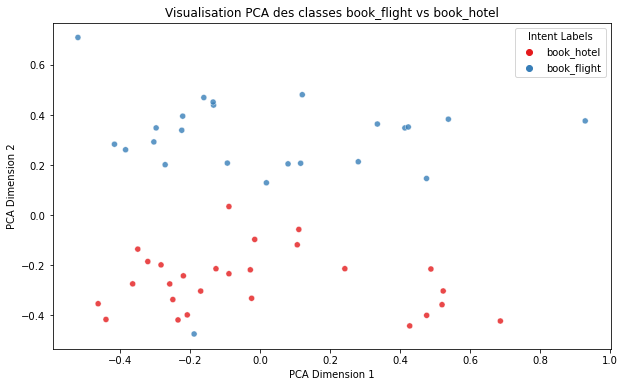

In [16]:
plot_pca_two_classes(df, "book_flight", "book_hotel")

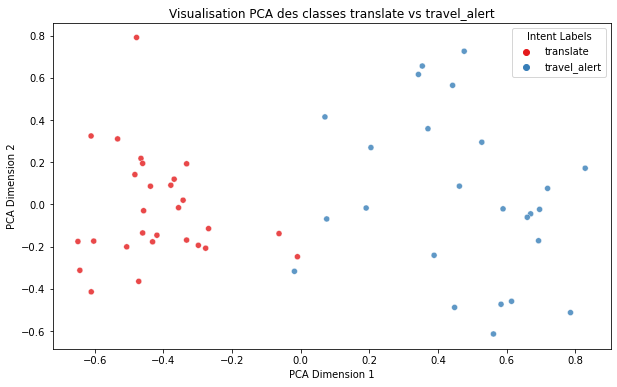

In [17]:
plot_pca_two_classes(df, "translate", "travel_alert")


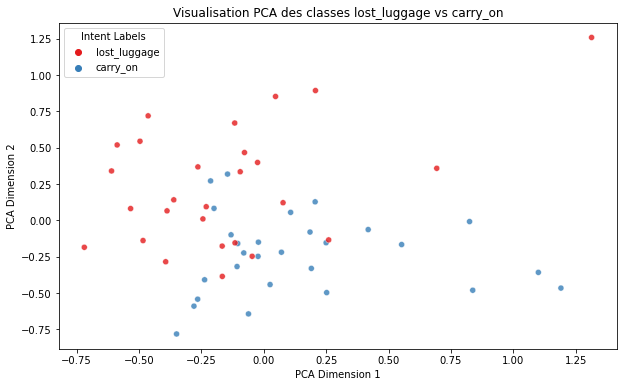

In [18]:
plot_pca_two_classes(df, "lost_luggage", "carry_on")



# Entraînement du modèle SVM

In [19]:
# Convertir en format utilisable par SVM
X = np.vstack(df["embeddings"].values)
y = df["label"]

# Encoder les labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in splitter.split(X, y_encoded):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]


svm_model = SVC(kernel="linear", probability=True)  # Activer probability=True pour récupérer les scores de confiance
svm_model.fit(X_train, y_train)

# Prédictions
y_pred = svm_model.predict(X_test)

# Évaluation du modèle
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Accuracy: 0.8867924528301887
                   precision    recall  f1-score   support

      book_flight       1.00      1.00      1.00         5
       book_hotel       1.00      0.60      0.75         5
         carry_on       1.00      1.00      1.00         6
    flight_status       1.00      0.80      0.89         5
     lost_luggage       0.83      1.00      0.91         5
     out_of_scope       0.75      0.90      0.82        10
        translate       1.00      0.83      0.91         6
     travel_alert       0.71      1.00      0.83         5
travel_suggestion       1.00      0.83      0.91         6

         accuracy                           0.89        53
        macro avg       0.92      0.89      0.89        53
     weighted avg       0.91      0.89      0.89        53



In [20]:

# Fonction de prédiction avec gestion de la classe inconnue
def predict_with_threshold(text, threshold=0.5):
    embedding = get_embeddings(preprocess_text(text)).reshape(1, -1)
    probs = svm_model.predict_proba(embedding)
    max_prob = np.max(probs)
    predicted_label = np.argmax(probs)

    if max_prob < threshold:
        return "out_of_scope"  # Classe inconnue
    return label_encoder.inverse_transform([predicted_label])[0]




In [22]:
# Exemple d'utilisation
texte_test = "où je dois mettre mon baggage ?"
print("Prédiction :", predict_with_threshold(texte_test, threshold=0.5))

Prédiction : out_of_scope


In [23]:
# Exemple d'utilisation
texte_test = "où je dois mettre mon baggage ?"
print("Prédiction :", predict_with_threshold(texte_test, threshold=0.2))

Prédiction : carry_on


In [25]:
# Exemple d'utilisation
texte_test = "je veux dire bojour en arabe"
print("Prédiction :", predict_with_threshold(texte_test, threshold=0.5))

Prédiction : translate
